# Topic 2: Neural Network Overview
## How Neural Networks Process Information

> **Goal:** Understand how data flows through a neural network and how it learns.

---
## 1. Quick Recap: What is a Neural Network?

A neural network is a team of tiny workers (neurons) organized in layers:

- **Input Layer**: Receives raw data (like pixels of an image)
- **Hidden Layers**: Process the data (where the magic happens)
- **Output Layer**: Gives the final answer

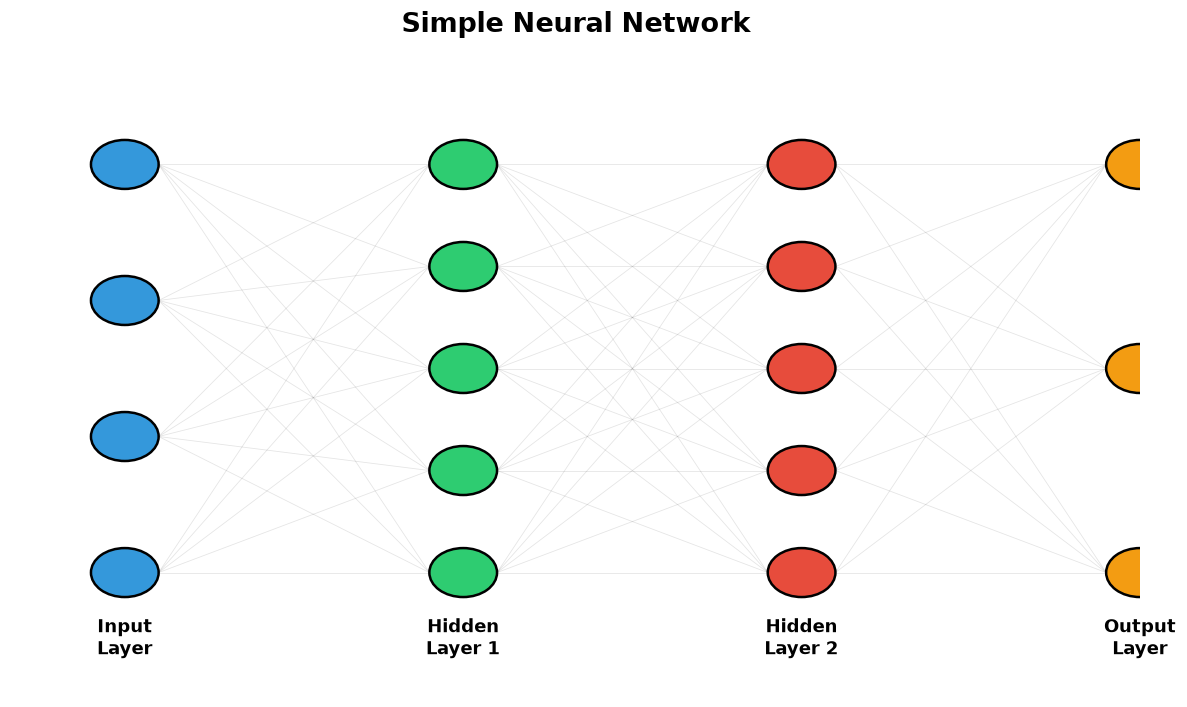

Each circle is a neuron. Lines show connections between neurons.
Data flows from left (input) to right (output).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Let's visualize a simple neural network
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Simple Neural Network', fontsize=16, fontweight='bold')

# Draw layers
layer_names = ['Input\nLayer', 'Hidden\nLayer 1', 'Hidden\nLayer 2', 'Output\nLayer']
layer_x = [1, 4, 7, 10]
layer_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
layer_sizes = [4, 5, 5, 3]

for i, (x, name, color, size) in enumerate(zip(layer_x, layer_names, layer_colors, layer_sizes)):
    y_positions = np.linspace(1.5, 6.5, size)
    for y in y_positions:
        circle = plt.Circle((x, y), 0.3, color=color, ec='black', linewidth=1.5)
        ax.add_patch(circle)
    ax.text(x, 0.5, name, ha='center', fontsize=11, fontweight='bold')

# Draw connections between layers
for i in range(len(layer_x) - 1):
    x1, x2 = layer_x[i], layer_x[i+1]
    y1 = np.linspace(1.5, 6.5, layer_sizes[i])
    y2 = np.linspace(1.5, 6.5, layer_sizes[i+1])
    for y_start in y1:
        for y_end in y2:
            ax.plot([x1+0.3, x2-0.3], [y_start, y_end], 'k-', alpha=0.1, linewidth=0.5)

plt.tight_layout()
plt.show()

print("Each circle is a neuron. Lines show connections between neurons.")
print("Data flows from left (input) to right (output).")

---
## 2. How Does a Neuron Work?

Each neuron does just **two things**:
1. **Multiply and Add**: Each input × weight, then add bias
2. **Activate**: Pass through activation function

In [2]:
# Let's see a neuron in action!
print("=" * 50)
print("HOW A NEURON WORKS")
print("=" * 50)

# Example: Simple neuron with 2 inputs
input1 = 0.5
input2 = 0.8
weight1 = 0.3
weight2 = 0.7
bias = 0.1

print(f"\nInputs: {input1}, {input2}")
print(f"Weights: {weight1}, {weight2}")
print(f"Bias: {bias}")

# Step 1: Weighted sum
weighted_sum = (input1 * weight1) + (input2 * weight2) + bias
print(f"\nStep 1 - Weighted Sum:")
print(f"  ({input1} × {weight1}) + ({input2} × {weight2}) + {bias}")
print(f"  = {input1 * weight1} + {input2 * weight2} + {bias}")
print(f"  = {weighted_sum}")

# Step 2: Apply ReLU activation
def relu(x):
    return max(0, x)

output = relu(weighted_sum)
print(f"\nStep 2 - ReLU Activation:")
print(f"  If {weighted_sum} > 0, output = {weighted_sum}")
print(f"  Final output: {output}")

print("\nThat's it! That's all a neuron does!")

HOW A NEURON WORKS

Inputs: 0.5, 0.8
Weights: 0.3, 0.7
Bias: 0.1

Step 1 - Weighted Sum:
  (0.5 × 0.3) + (0.8 × 0.7) + 0.1
  = 0.15 + 0.5599999999999999 + 0.1
  = 0.8099999999999999

Step 2 - ReLU Activation:
  If 0.8099999999999999 > 0, output = 0.8099999999999999
  Final output: 0.8099999999999999

That's it! That's all a neuron does!


---
## 3. Activation Functions

Activation functions decide how much signal to pass forward. Without them, the network could only learn straight-line patterns.

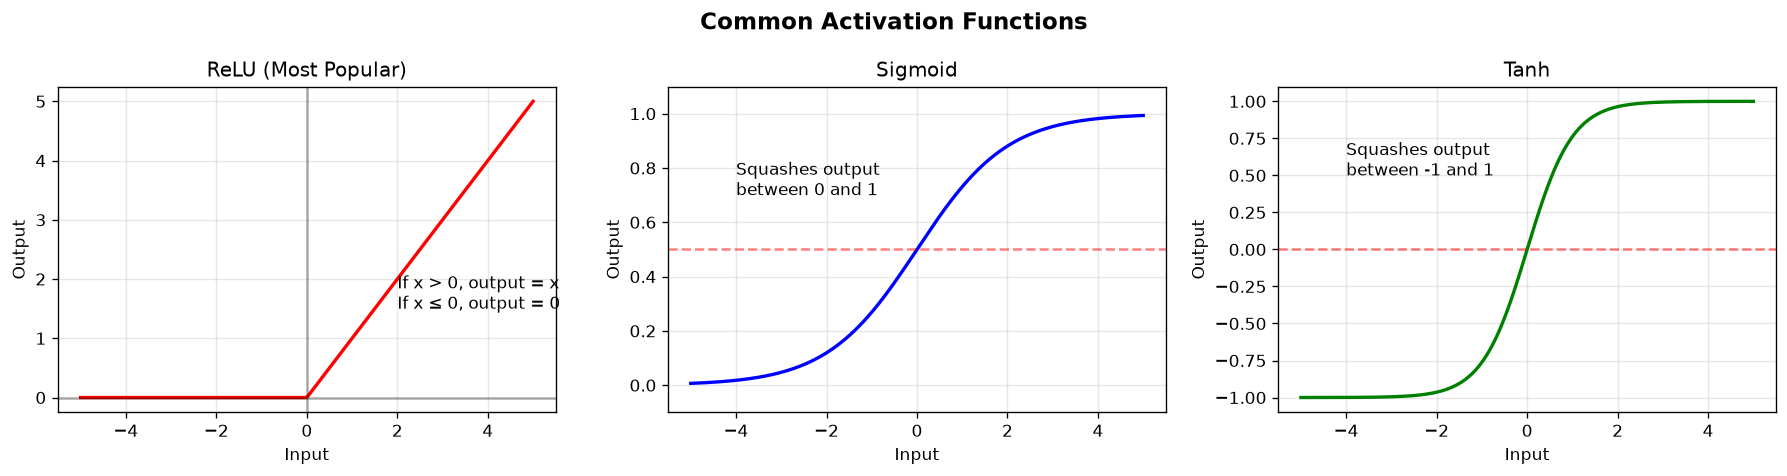


Key Points:
- ReLU is most popular: simple and fast
- Sigmoid: good for yes/no questions
- Tanh: like sigmoid but centered at 0


In [3]:
# Let's visualize the main activation functions
x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Common Activation Functions', fontsize=14, fontweight='bold')

# ReLU - Most popular!
relu = np.maximum(0, x)
axes[0].plot(x, relu, 'r-', linewidth=2)
axes[0].set_title('ReLU (Most Popular)', fontsize=12)
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0].text(2, 1.5, 'If x > 0, output = x\nIf x ≤ 0, output = 0', fontsize=10)

# Sigmoid
sigmoid = 1 / (1 + np.exp(-x))
axes[1].plot(x, sigmoid, 'b-', linewidth=2)
axes[1].set_title('Sigmoid', fontsize=12)
axes[1].set_xlabel('Input')
axes[1].set_ylabel('Output')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
axes[1].set_ylim(-0.1, 1.1)
axes[1].text(-4, 0.7, 'Squashes output\nbetween 0 and 1', fontsize=10)

# Tanh
tanh = np.tanh(x)
axes[2].plot(x, tanh, 'g-', linewidth=2)
axes[2].set_title('Tanh', fontsize=12)
axes[2].set_xlabel('Input')
axes[2].set_ylabel('Output')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[2].set_ylim(-1.1, 1.1)
axes[2].text(-4, 0.5, 'Squashes output\nbetween -1 and 1', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey Points:")
print("- ReLU is most popular: simple and fast")
print("- Sigmoid: good for yes/no questions")
print("- Tanh: like sigmoid but centered at 0")

---
## 4. Loss Functions (How Wrong Are We?)

The loss function measures how far our predictions are from the correct answers.

LOSS FUNCTIONS EXPLAINED

1. Mean Squared Error (MSE) - For Predicting Numbers
--------------------------------------------------
Actual prices:    [200, 300, 250, 400]
Predicted prices: [210, 280, 260, 380]

Errors:          [-10, 20, -10, 20]
Squared Errors:  [100, 400, 100, 400]
MSE (average):   250.00

Squaring makes big errors hurt more!

2. Cross-Entropy Loss - For Classification
--------------------------------------------------
Example: Is this a cat or dog?
True answer: Cat (100% confident)
Model predicts: 70% Cat, 30% Dog

Cross-Entropy heavily penalizes confident wrong answers!


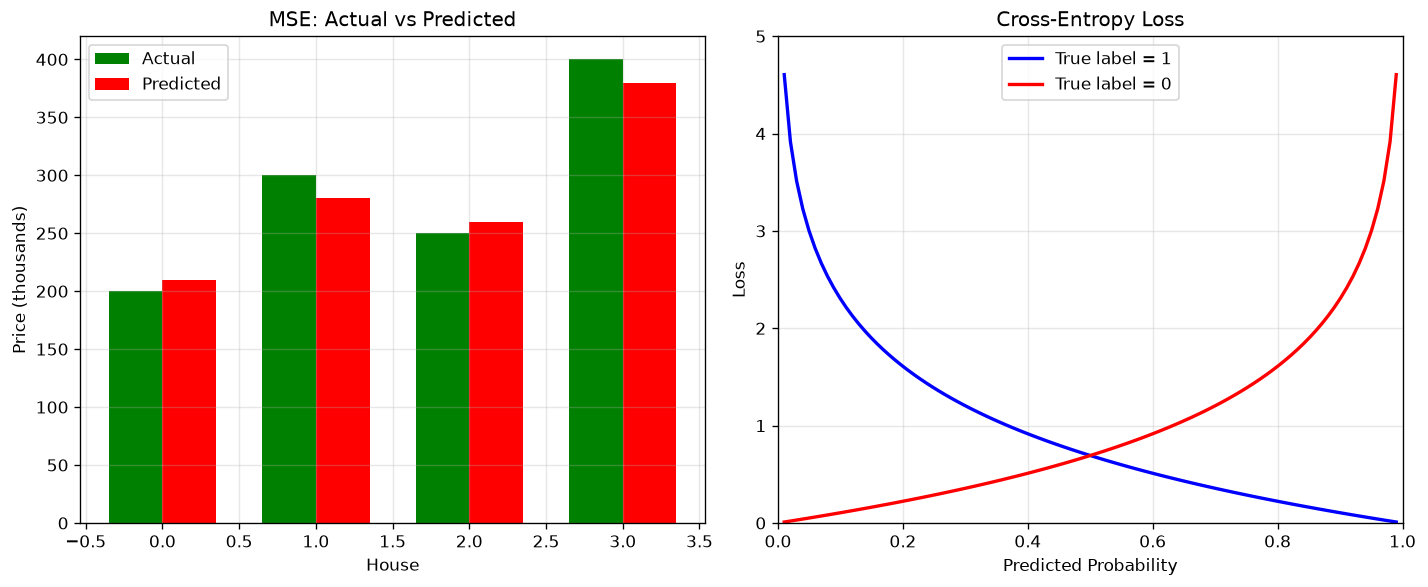


Notice: If we predict 0.1 when true is 1 → HUGE loss!
If we predict 0.9 when true is 1 → tiny loss.


In [4]:
# Let's see how loss works
print("=" * 50)
print("LOSS FUNCTIONS EXPLAINED")
print("=" * 50)

# Example 1: Mean Squared Error (for predicting numbers)
print("\n1. Mean Squared Error (MSE) - For Predicting Numbers")
print("-" * 50)

actual_house_price = [200, 300, 250, 400]  # in thousands
predicted_price = [210, 280, 260, 380]

print(f"Actual prices:    {actual_house_price}")
print(f"Predicted prices: {predicted_price}")

# Calculate MSE
errors = [a - p for a, p in zip(actual_house_price, predicted_price)]
squared_errors = [e**2 for e in errors]
mse = np.mean(squared_errors)

print(f"\nErrors:          {errors}")
print(f"Squared Errors:  {squared_errors}")
print(f"MSE (average):   {mse:.2f}")
print(f"\nSquaring makes big errors hurt more!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pos = range(len(actual_house_price))
width = 0.35
axes[0].bar([i - width/2 for i in x_pos], actual_house_price, width, label='Actual', color='green')
axes[0].bar([i + width/2 for i in x_pos], predicted_price, width, label='Predicted', color='red')
axes[0].set_xlabel('House')
axes[0].set_ylabel('Price (thousands)')
axes[0].set_title('MSE: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Example 2: Cross-Entropy (for classification)
print("\n2. Cross-Entropy Loss - For Classification")
print("-" * 50)
print("Example: Is this a cat or dog?")
print("True answer: Cat (100% confident)")
print("Model predicts: 70% Cat, 30% Dog")
print("\nCross-Entropy heavily penalizes confident wrong answers!")

# Visualize cross-entropy
x_ce = np.linspace(0.01, 0.99, 100)
loss_when_true = -np.log(x_ce)
loss_when_false = -np.log(1 - x_ce)

axes[1].plot(x_ce, loss_when_true, 'b-', linewidth=2, label='True label = 1')
axes[1].plot(x_ce, loss_when_false, 'r-', linewidth=2, label='True label = 0')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Loss')
axes[1].set_title('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

print("\nNotice: If we predict 0.1 when true is 1 → HUGE loss!")
print("If we predict 0.9 when true is 1 → tiny loss.")

---
## 5. Gradient Descent (How the Network Learns)

**The Mountain Analogy:**
Imagine you're on a mountain in thick fog and want to reach the lowest point:
1. Feel the slope under your feet (that's the **gradient**)
2. Take a step downhill (that's the **update**)
3. Repeat until you reach the bottom

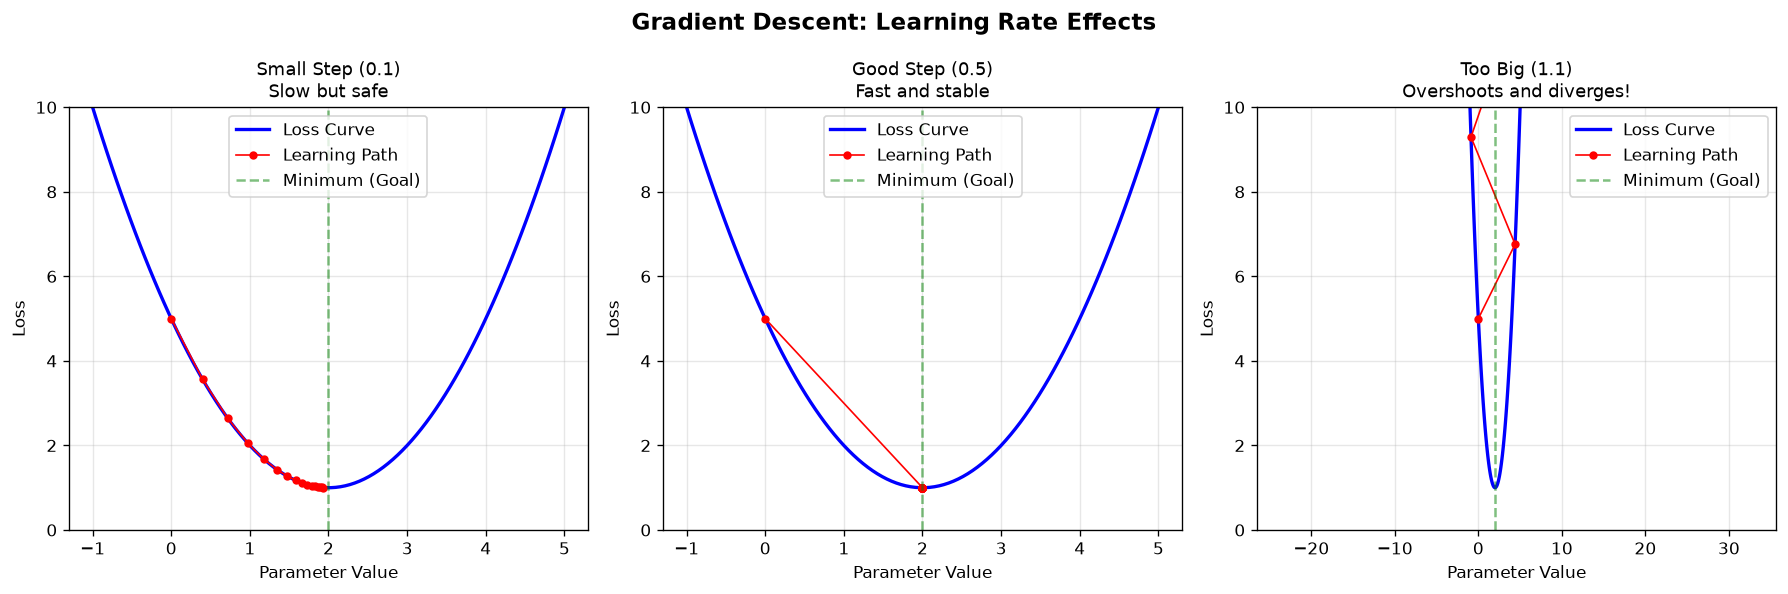


Learning Rate Tips:
- Too small: Very slow, might get stuck
- Just right: Fast and reaches the minimum
- Too large: Overshoots, never finds the minimum!


In [5]:
# Let's see gradient descent in action!
def loss_function(x):
    return (x - 2) ** 2 + 1  # Minimum at x = 2

def gradient(x):
    return 2 * (x - 2)

x = np.linspace(-1, 5, 100)
y = loss_function(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Gradient Descent: Learning Rate Effects', fontsize=14, fontweight='bold')

# Try different learning rates
learning_rates = [0.1, 0.5, 1.1]
titles = ['Small Step (0.1)\nSlow but safe', 
          'Good Step (0.5)\nFast and stable', 
          'Too Big (1.1)\nOvershoots and diverges!']

for idx, (lr, title) in enumerate(zip(learning_rates, titles)):
    axes[idx].plot(x, y, 'b-', linewidth=2, label='Loss Curve')
    
    # Start at x = 0 and take steps
    x_current = 0.0
    trajectory_x = [x_current]
    trajectory_y = [loss_function(x_current)]
    
    for _ in range(15):
        grad = gradient(x_current)
        x_current = x_current - lr * grad
        trajectory_x.append(x_current)
        trajectory_y.append(loss_function(x_current))
    
    axes[idx].plot(trajectory_x, trajectory_y, 'ro-', markersize=4, linewidth=1, label='Learning Path')
    axes[idx].axvline(x=2, color='g', linestyle='--', alpha=0.5, label='Minimum (Goal)')
    axes[idx].set_xlabel('Parameter Value')
    axes[idx].set_ylabel('Loss')
    axes[idx].set_title(title, fontsize=11)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(0, 10)

plt.tight_layout()
plt.show()

print("\nLearning Rate Tips:")
print("- Too small: Very slow, might get stuck")
print("- Just right: Fast and reaches the minimum")
print("- Too large: Overshoots, never finds the minimum!")

---
## 6. The Training Loop

The network learns by repeating these steps:

THE TRAINING LOOP IN ACTION

Goal: Learn that output = 2 × input
Initial weight: 0.0050 (should become ~2.0)
Initial bias: 0.0000 (should become ~0.0)

Training...
--------------------------------------------------
Epoch  50: Loss = 0.0090, Weight = 1.9394, Bias = 0.2188
Epoch 100: Loss = 0.0016, Weight = 1.9742, Bias = 0.0933
Epoch 150: Loss = 0.0003, Weight = 1.9890, Bias = 0.0398
Epoch 200: Loss = 0.0001, Weight = 1.9953, Bias = 0.0170
Epoch 250: Loss = 0.0000, Weight = 1.9980, Bias = 0.0072
Epoch 300: Loss = 0.0000, Weight = 1.9991, Bias = 0.0031

TRAINING COMPLETE!
Final weight: 1.9991 (started at ~0.0, should be ~2.0)
Final bias: 0.0031 (started at 0.0, should be ~0.0)


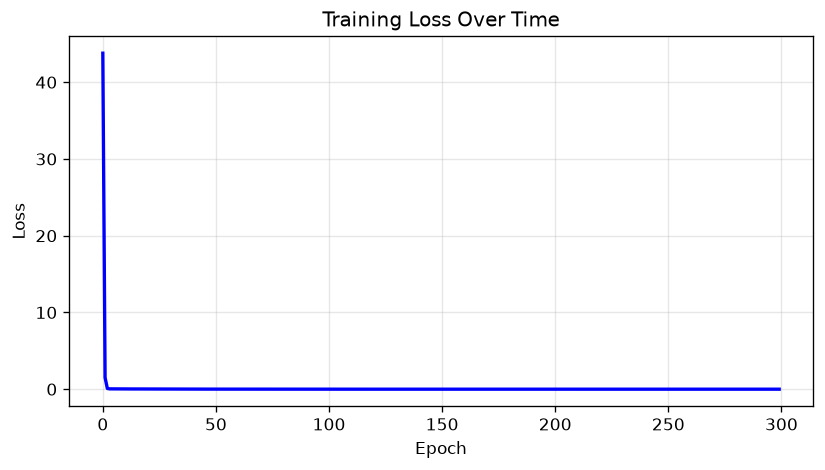

Loss decreases as the network learns, and weight/bias converge to the true values!


In [6]:
# Simple training example
print("=" * 50)
print("THE TRAINING LOOP IN ACTION")
print("=" * 50)

# Simple problem: learn that output = 2 × input
X = np.array([[1], [2], [3], [4], [5]])  # inputs
y_true = np.array([[2], [4], [6], [8], [10]])  # expected output

# Initialize with random weights
np.random.seed(42)
W = np.random.randn(1, 1) * 0.01  # weight
b = np.zeros((1, 1))  # bias

print(f"\nGoal: Learn that output = 2 × input")
print(f"Initial weight: {W[0][0]:.4f} (should become ~2.0)")
print(f"Initial bias: {b[0][0]:.4f} (should become ~0.0)")

# Training
learning_rate = 0.05
losses = []

print("\nTraining...")
print("-" * 50)

for epoch in range(300):
    # Forward pass
    y_pred = X.dot(W) + b
    
    # Compute loss (MSE)
    loss = np.mean((y_true - y_pred) ** 2)
    losses.append(loss)
    
    # Backward pass (compute gradients)
    error = y_pred - y_true
    dW = 2 * np.mean(X * error)
    db = 2 * np.mean(error)
    
    # Update weights
    W -= learning_rate * dW
    b -= learning_rate * db
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss:.4f}, Weight = {W[0][0]:.4f}, Bias = {b[0][0]:.4f}")

print("\n" + "=" * 50)
print("TRAINING COMPLETE!")
print(f"Final weight: {W[0][0]:.4f} (started at ~0.0, should be ~2.0)")
print(f"Final bias: {b[0][0]:.4f} (started at 0.0, should be ~0.0)")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print("Loss decreases as the network learns, and weight/bias converge to the true values!")

---
## 7. Putting It All Together

Let's build a simple neural network that learns to classify points:

BUILDING A NEURAL NETWORK

Network: 2 inputs → 10 hidden → 1 output
Total parameters: 41

Training...
Epoch  50: Loss = 0.1229, Accuracy = 86.00%
Epoch 100: Loss = 0.0571, Accuracy = 95.00%
Epoch 150: Loss = 0.0310, Accuracy = 99.00%
Epoch 200: Loss = 0.0195, Accuracy = 99.00%


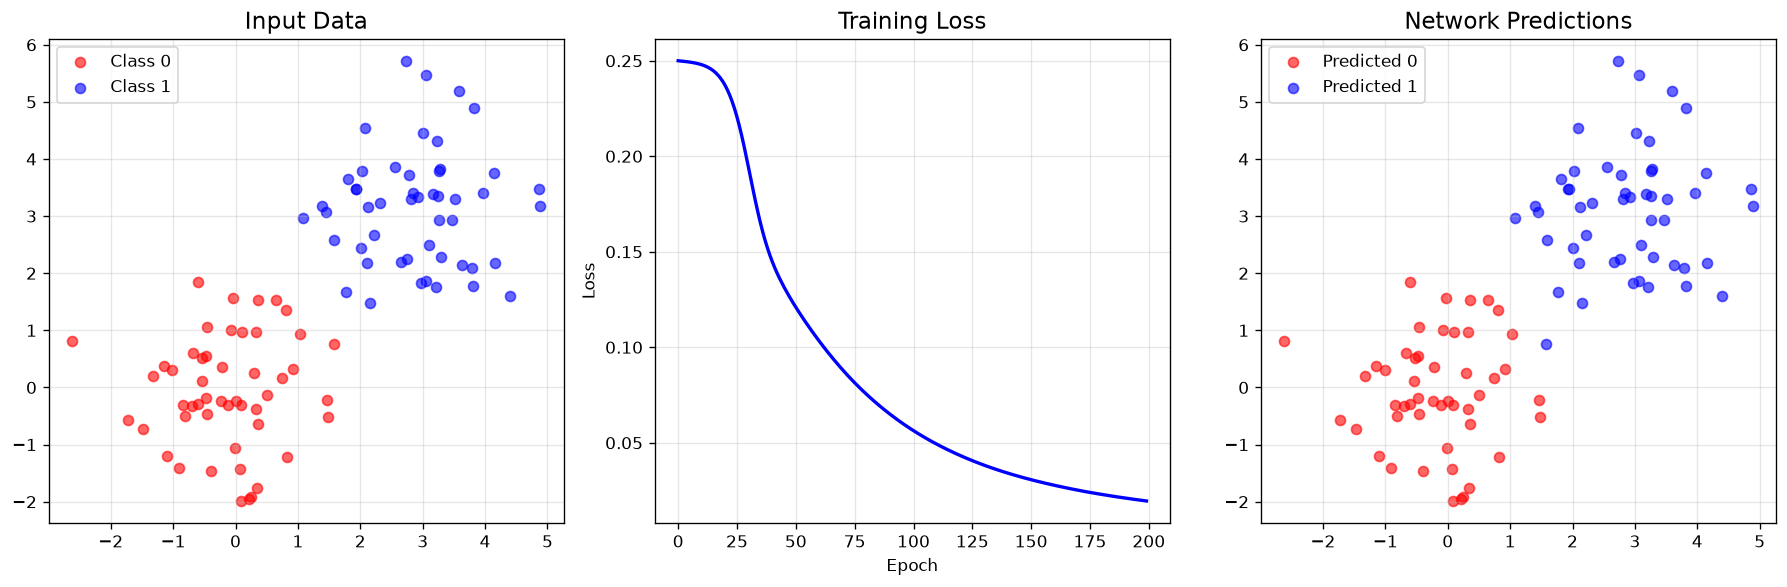


The network learned to separate the two classes!


In [7]:
# Simple neural network for classification
print("=" * 50)
print("BUILDING A NEURAL NETWORK")
print("=" * 50)

np.random.seed(42)

# Generate simple data: 2 classes of points
n_points = 50
class_0 = np.random.randn(n_points, 2) + np.array([0, 0])
class_1 = np.random.randn(n_points, 2) + np.array([3, 3])
X = np.vstack([class_0, class_1])
y = np.array([0]*n_points + [1]*n_points)

# Simple 2-layer network
input_dim = 2
hidden_dim = 10
output_dim = 1

# Initialize weights
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))

print(f"\nNetwork: {input_dim} inputs → {hidden_dim} hidden → {output_dim} output")
print(f"Total parameters: {input_dim * hidden_dim + hidden_dim + hidden_dim * output_dim + output_dim}")

# Training
lr = 0.1
losses = []

print("\nTraining...")
for epoch in range(200):
    # Forward pass
    z1 = X.dot(W1) + b1
    a1 = np.maximum(0, z1)  # ReLU
    z2 = a1.dot(W2) + b2
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid
    
    # Compute loss
    loss = np.mean((y.reshape(-1, 1) - a2) ** 2)
    losses.append(loss)
    
    # Backward pass
    dz2 = a2 - y.reshape(-1, 1)
    dW2 = a1.T.dot(dz2) / len(X)
    db2 = np.mean(dz2, axis=0, keepdims=True)
    
    da1 = dz2.dot(W2.T)
    dz1 = da1 * (z1 > 0)  # ReLU derivative
    dW1 = X.T.dot(dz1) / len(X)
    db1 = np.mean(dz1, axis=0, keepdims=True)
    
    # Update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1
    
    if (epoch + 1) % 50 == 0:
        predictions = (a2 > 0.5).astype(int).flatten()
        accuracy = np.mean(predictions == y)
        print(f"Epoch {epoch+1:3d}: Loss = {loss:.4f}, Accuracy = {accuracy:.2%}")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot data
axes[0].scatter(class_0[:, 0], class_0[:, 1], c='red', label='Class 0', alpha=0.6)
axes[0].scatter(class_1[:, 0], class_1[:, 1], c='blue', label='Class 1', alpha=0.6)
axes[0].set_title('Input Data', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(losses, 'b-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Plot predictions
predictions = (a2 > 0.5).astype(int).flatten()
axes[2].scatter(X[predictions == 0, 0], X[predictions == 0, 1], c='red', label='Predicted 0', alpha=0.6)
axes[2].scatter(X[predictions == 1, 0], X[predictions == 1, 1], c='blue', label='Predicted 1', alpha=0.6)
axes[2].set_title('Network Predictions', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nThe network learned to separate the two classes!")

---
## 8. Key Takeaways

### What We Learned:
1. **Neurons** do simple math: weighted sum + activation
2. **Forward Propagation** flows data from input to output
3. **Activation Functions** (ReLU is most popular) add non-linearity
4. **Loss Functions** measure how wrong predictions are
5. **Gradient Descent** adjusts weights to reduce loss
6. **Training Loop** repeats: forward → loss → backward → update

### The Big Picture:
> Neural networks learn by adjusting millions of weights through **forward propagation**, **loss calculation**, and **gradient descent** until they get good at their task.